In [362]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [363]:
pd.set_option("display.max_columns", None)

In [364]:
df = pd.read_csv("house_data_unianalysis.csv")
df.head()

,society,bedrooms,baths,nearby_locations_and_other_facilities,rooms,link,floors,furnished,other_business_and_communication_facilities,other_community_facilities,lawn_or_garden,other_healthcare_and_recreation_facilities,price,area,area_sqft,servant_quarters,kitchens,store_rooms,total_rooms,price_per_sqft,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,servant_quarters_flag,store_rooms_flag,kitchens_flag,other_rooms,luxury_score,furnishing_score,agePossession
0,DHA Defence,6.0,6.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '6', 'Bathrooms': '7', 'Servant Q...",https://www.zameen.com/Property/dha_defence_dh...,2.0,True,True,True,True,True,19.75,40.0,10890.04,2.0,2.0,2.0,4.0,18152.573529,1,1,1,1,1,1,1,1,1,0,0,0,1,66,25,New Property
1,DHA Defence,6.0,7.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '6', 'Bathrooms': '7', 'Servant Q...",https://www.zameen.com/Property/dha_defence_dh...,2.0,True,True,True,True,True,11.50,20.0,5445.02,2.0,3.0,2.0,5.0,21139.705882,1,1,1,1,1,1,1,1,1,0,0,0,1,66,25,New Property
2,DHA Defence,6.0,7.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '6', 'Bathrooms': '7', 'Servant Q...",https://www.zameen.com/Property/dha_defence_dh...,2.0,True,True,True,True,True,28.50,40.0,10890.04,2.0,3.0,1.0,4.0,26194.852941,1,1,1,1,1,1,1,1,1,0,0,0,0,66,25,New Property
3,DHA Defence,5.0,6.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '5', 'Bathrooms': '5', 'Servant Q...",https://www.zameen.com/Property/dha_defence_dh...,2.0,True,True,True,True,True,9.25,20.0,5445.02,2.0,3.0,1.0,4.0,17003.676471,1,1,1,1,1,1,1,1,1,0,0,0,1,66,25,New Property
4,DHA Defence,5.0,6.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '2', 'Bathrooms': '2', 'Servant Q...",https://www.zameen.com/Property/dha_phase_7_dh...,2.0,True,True,True,True,True,7.15,20.0,5445.02,2.0,1.0,NaN,NaN,13143.382353,1,1,1,1,1,1,1,1,1,0,1,0,1,66,25,New Property


In [365]:
df.shape

(21219, 36)

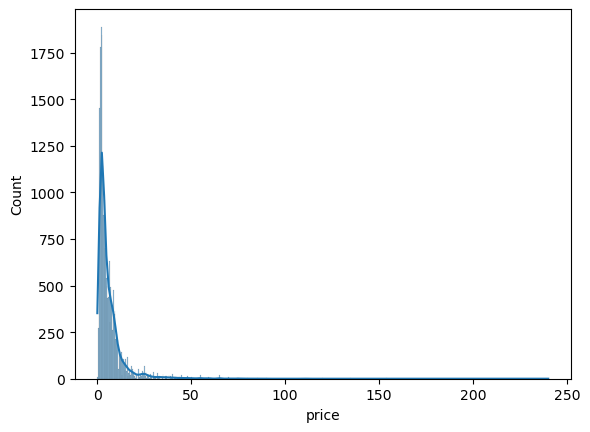

In [366]:
sns.histplot(df['price'], kde=True)  # distplot is deprecated
plt.show()

<Axes: xlabel='price'>

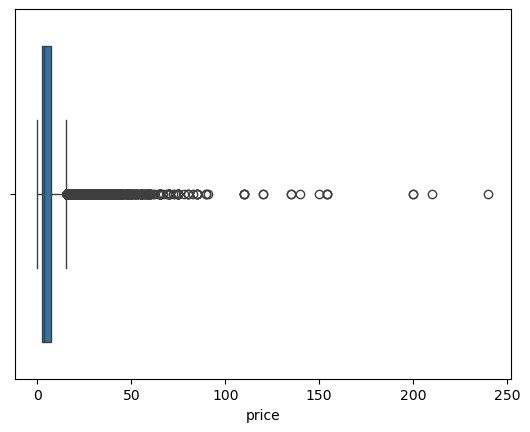

In [367]:
sns.boxplot(x=df['price'])

In [368]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Display number of outliers and stats
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(1491,
 count    1491.000000
 mean       29.457418
 std        19.111046
 min        15.500000
 25%        18.500000
 50%        24.000000
 75%        33.745000
 max       240.000000
 Name: price, dtype: float64)

In [369]:
outliers.sort_values('price', ascending=False).head(21)

,society,bedrooms,baths,nearby_locations_and_other_facilities,rooms,link,floors,furnished,other_business_and_communication_facilities,other_community_facilities,lawn_or_garden,other_healthcare_and_recreation_facilities,price,area,area_sqft,servant_quarters,kitchens,store_rooms,total_rooms,price_per_sqft,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,servant_quarters_flag,store_rooms_flag,kitchens_flag,other_rooms,luxury_score,furnishing_score,agePossession
16331,Gulberg,11.0,7.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '31', 'Bathrooms': '15', 'Servant...",https://www.zameen.com/Property/lahore_gulberg...,2.0,NaN,True,True,True,True,240.0,160.0,43560.160,3.0,3.0,NaN,NaN,55147.058824,1,1,1,1,1,1,1,0,0,0,1,0,1,46,12,Old Property
16328,Gulberg,NaN,NaN,NaN,{},https://www.zameen.com/Property/gulberg_gulber...,NaN,NaN,NaN,NaN,NaN,NaN,210.0,156.0,42471.156,NaN,NaN,NaN,NaN,49490.950226,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,Undefined
16385,Gulberg,2.0,3.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '2', 'Bathrooms': '3', 'Kitchens'...",https://www.zameen.com/Property/lahore_gulberg...,2.0,True,True,True,True,True,200.0,160.0,43560.160,NaN,1.0,1.0,2.0,45955.882353,1,1,1,1,1,1,1,1,1,1,0,0,1,66,25,Relatively New
16438,Gulberg,11.0,7.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '5', 'Bathrooms': '5', 'Kitchens'...",https://www.zameen.com/Property/gulberg_main_b...,2.0,NaN,True,True,True,True,200.0,160.0,43560.160,NaN,2.0,NaN,NaN,45955.882353,1,1,1,1,1,1,0,0,0,1,1,0,1,66,15,Moderately Old
16316,Gulberg,10.0,6.0,NaN,{},https://www.zameen.com/Property/lahore_gulberg...,NaN,NaN,NaN,NaN,NaN,NaN,154.0,140.0,38115.140,NaN,NaN,NaN,NaN,40441.176471,1,1,0,0,0,0,0,0,0,1,1,1,0,31,7,New Property
16281,Gulberg,10.0,6.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '1', 'Bathrooms': '1', 'Kitchens'...",https://www.zameen.com/Property/gulberg_main_b...,NaN,NaN,NaN,NaN,NaN,NaN,154.0,140.0,38115.140,NaN,1.0,NaN,NaN,40441.176471,0,0,0,0,0,0,0,0,0,0,0,0,0,31,5,Relatively New
16315,Gulberg,10.0,6.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...",{},https://www.zameen.com/Property/gulberg_libert...,NaN,NaN,NaN,NaN,NaN,NaN,154.0,140.0,38115.140,NaN,NaN,NaN,NaN,40441.176471,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,Undefined
18364,Garden Town,10.0,6.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '15', 'Bathrooms': '15', 'Servant...",https://www.zameen.com/Property/lahore_garden_...,NaN,NaN,NaN,NaN,NaN,NaN,150.0,200.0,54450.200,4.0,2.0,2.0,4.0,27573.529412,1,1,1,1,0,0,1,0,0,0,0,0,0,24,10,Undefined
18312,Garden Town,10.0,6.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '5', 'Bathrooms': '5', 'Servant Q...",https://www.zameen.com/Property/lahore_garden_...,2.0,NaN,True,True,True,True,140.0,280.0,76230.280,2.0,1.0,1.0,2.0,18382.352941,1,1,1,1,1,1,1,1,1,0,0,0,1,66,15,New Property
16288,Gulberg,10.0,7.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '7', 'Bathrooms': '7', 'Servant Q...",https://www.zameen.com/Property/gulberg_3_gulb...,2.0,True,NaN,NaN,True,NaN,135.0,140.0,38115.140,3.0,2.0,2.0,4.0,35451.680672,1,1,1,1,1,1,1,0,1,0,0,0,1,27,18,Undefined


In [370]:
df.shape

(21219, 36)

In [371]:
df.shape

(21219, 36)

In [372]:
df = df[df['price'] <= 45]

<Axes: xlabel='price'>

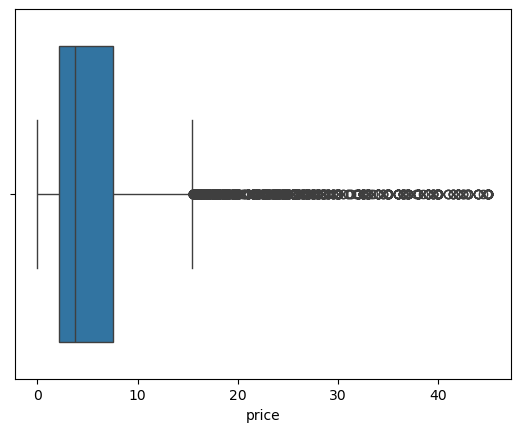

In [373]:
sns.boxplot(x=df['price'])

## price_per_sqft

<Axes: xlabel='price_per_sqft', ylabel='Count'>

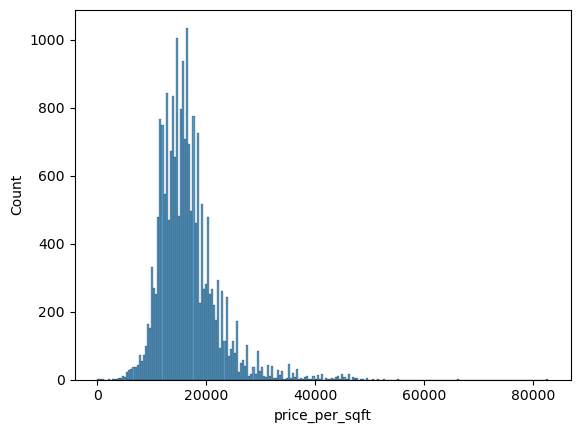

In [374]:
sns.histplot(df["price_per_sqft"])


<Axes: xlabel='price_per_sqft'>

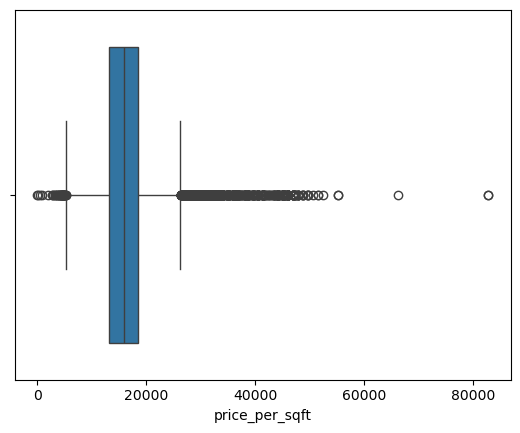

In [375]:
sns.boxplot(x=df["price_per_sqft"])

In [376]:
# Calculate IQR for price_per_sqft
Q1 = df["price_per_sqft"].quantile(0.25)
Q3 = df["price_per_sqft"].quantile(0.75)
IQR = Q3 - Q1

# Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Outliers
outliers_sqft = df[(df["price_per_sqft"] < lower_bound) | (df["price_per_sqft"] > upper_bound)]

# Count + stats
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft["price_per_sqft"].describe()

num_outliers, outliers_sqft_stats


(999,
 count      999.000000
 mean     31759.252523
 std       8617.776173
 min          2.022059
 25%      27573.529412
 50%      30330.882353
 75%      35368.354072
 max      82720.588235
 Name: price_per_sqft, dtype: float64)

In [377]:
df[df["price_per_sqft"] > 60000].shape

(3, 36)

In [378]:
df = df[df["price_per_sqft"] <= 60000]

<Axes: xlabel='price_per_sqft'>

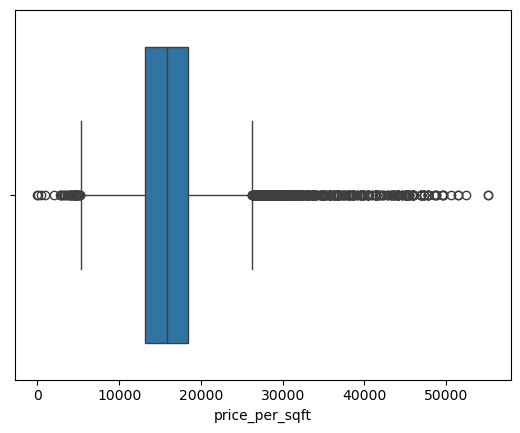

In [379]:
sns.boxplot(x=df["price_per_sqft"])

## area

<Axes: xlabel='area_sqft', ylabel='Count'>

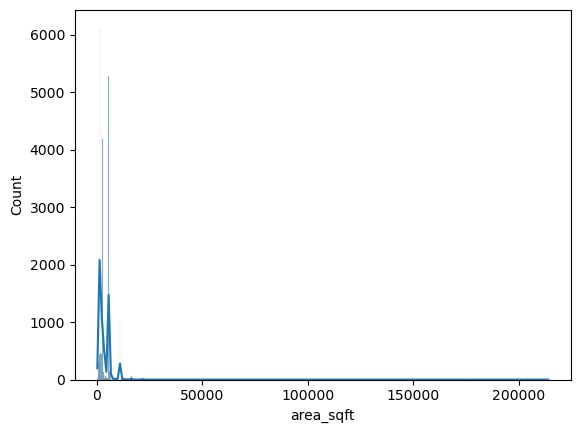

In [380]:
sns.histplot(df["area_sqft"], kde=True)

<Axes: xlabel='area_sqft'>

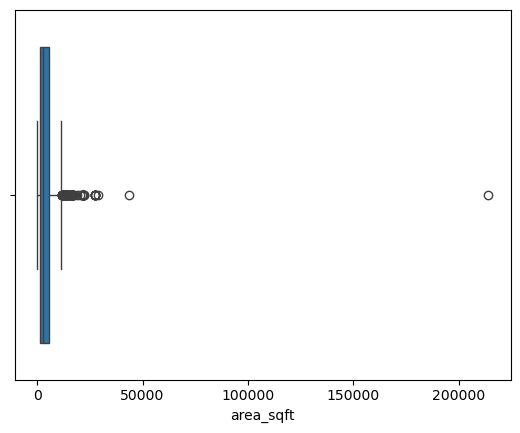

In [381]:
sns.boxplot(x=df["area_sqft"])


In [382]:
# Calculate the IQR for the 'price' column
Q1 = df['area_sqft'].quantile(0.25)
Q3 = df['area_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['area_sqft'] < lower_bound) | (df['area_sqft'] > upper_bound)]

# Display number of outliers and stats
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['area_sqft'].describe()

num_outliers, outliers_price_stats

(144,
 count       144.000000
 mean      18834.475431
 std       17003.766049
 min       11979.044000
 25%       14020.926500
 50%       16335.060000
 75%       21780.080000
 max      213989.286000
 Name: area_sqft, dtype: float64)

In [383]:
Q1 = df["area_sqft"].quantile(0.25)
Q3 = df["area_sqft"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound,upper_bound)

-4764.392500000001 11570.667500000001


In [384]:
df = df[df["area_sqft"] <= 20000]

<Axes: xlabel='area_sqft'>

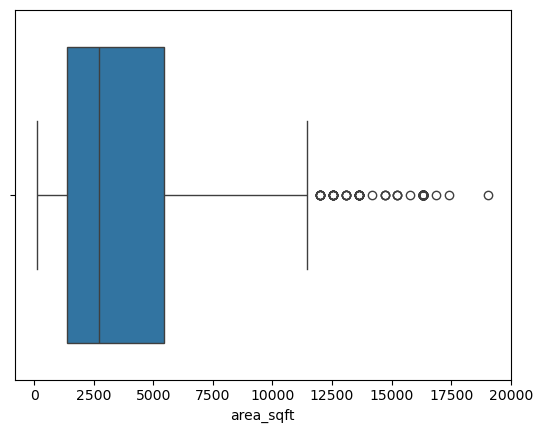

In [385]:
sns.boxplot(x=df["area_sqft"])


In [386]:
df.shape

(21004, 36)

<Axes: xlabel='area_sqft', ylabel='Count'>

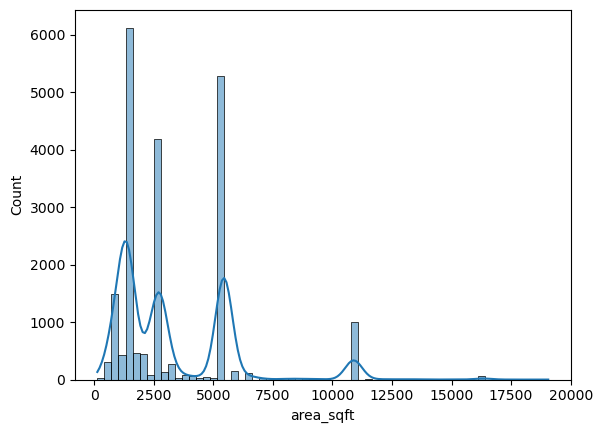

In [387]:
sns.histplot(df["area_sqft"], kde=True)

<Axes: xlabel='bedrooms', ylabel='Count'>

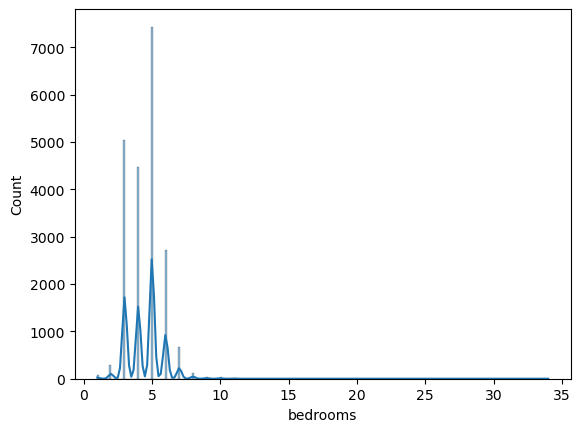

In [388]:
sns.histplot(df["bedrooms"], kde=True)

<Axes: xlabel='bedrooms'>

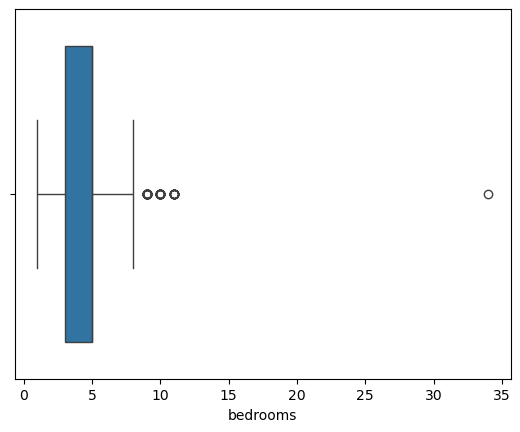

In [389]:
sns.boxplot(x=df["bedrooms"])


In [390]:
df['bedrooms'].describe()

count    20915.000000
mean         4.478413
std          1.235009
min          1.000000
25%          3.000000
50%          5.000000
75%          5.000000
max         34.000000
Name: bedrooms, dtype: float64

In [391]:
df[df["bedrooms"] > 6].sort_values("bedrooms", ascending=False)[['area','bedrooms']]

,area,bedrooms
6387,5.0,34.0
18391,42.0,11.0
806,40.0,11.0
18306,40.0,11.0
10352,20.0,11.0
...,...,...
587,20.0,7.0
566,40.0,7.0
21096,10.0,7.0
21091,40.0,7.0


In [392]:
df = df[df["bedrooms"] <= 20]

In [393]:
df.shape

(20914, 36)

<Axes: xlabel='bedrooms'>

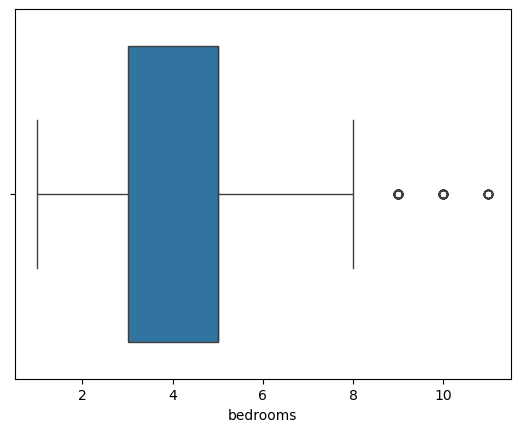

In [394]:
sns.boxplot(x=df["bedrooms"])


<Axes: xlabel='bedrooms', ylabel='Count'>

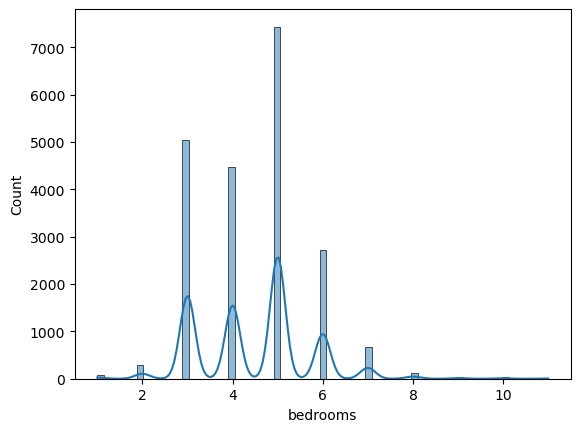

In [395]:
sns.histplot(df["bedrooms"], kde=True)


<Axes: xlabel='baths', ylabel='Count'>

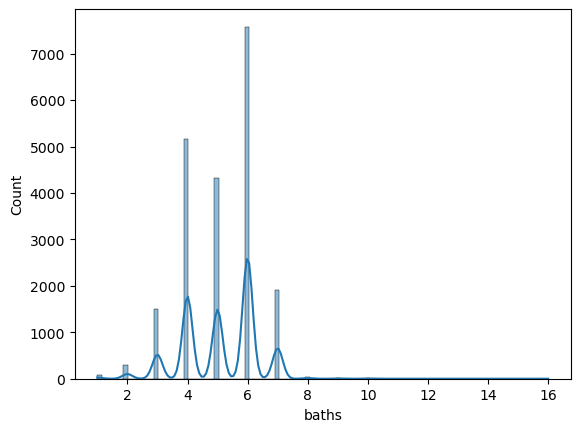

In [396]:
sns.histplot(df["baths"], kde=True)

<Axes: xlabel='baths'>

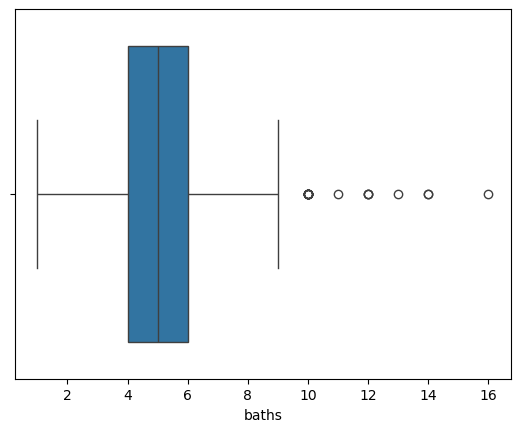

In [397]:
sns.boxplot(x=df["baths"])


In [398]:
df = df[df["baths"] <= 90]

<Axes: xlabel='baths'>

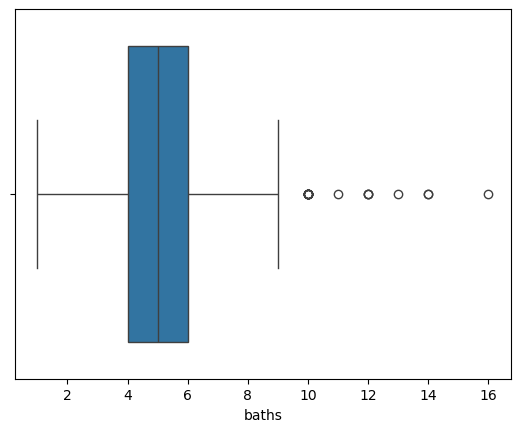

In [399]:
sns.boxplot(x=df["baths"])


<Axes: xlabel='kitchens', ylabel='Count'>

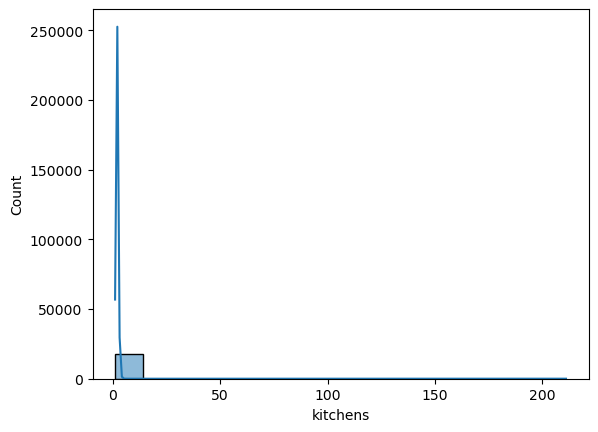

In [400]:
sns.histplot(df["kitchens"], kde=True)

<Axes: xlabel='kitchens'>

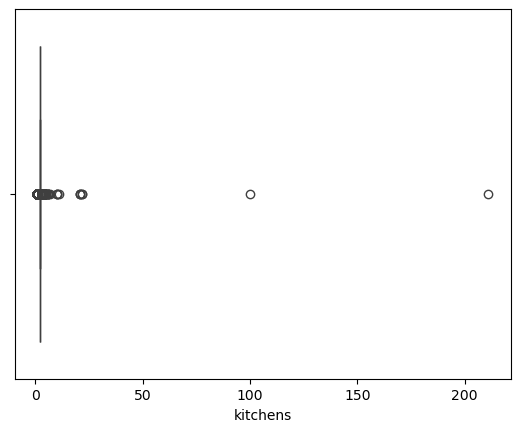

In [401]:
sns.boxplot(x=df["kitchens"])

In [402]:
# df = df[df["kitchens"] <= 90]

In [403]:
df.shape

(20903, 36)

<Axes: xlabel='servant_quarters', ylabel='Count'>

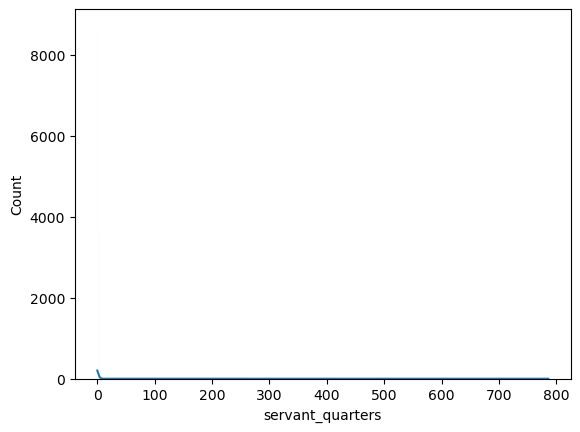

In [404]:
sns.histplot(df["servant_quarters"], kde=True)

<Axes: xlabel='servant_quarters'>

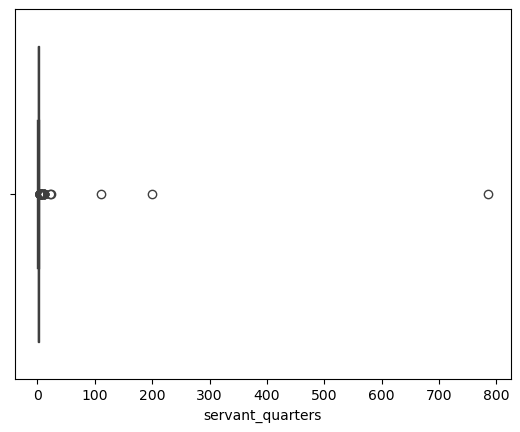

In [405]:
sns.boxplot(x=df["servant_quarters"])


In [406]:
df.isnull().sum()

society                                           0
bedrooms                                          0
baths                                             0
nearby_locations_and_other_facilities          1932
rooms                                             0
link                                              0
floors                                         6808
furnished                                      9385
other_business_and_communication_facilities    7690
other_community_facilities                     7965
lawn_or_garden                                 6662
other_healthcare_and_recreation_facilities     8614
price                                             0
area                                              0
area_sqft                                         0
servant_quarters                               8011
kitchens                                       3377
store_rooms                                    7368
total_rooms                                    7531
price_per_sq

<Axes: xlabel='luxury_score', ylabel='Count'>

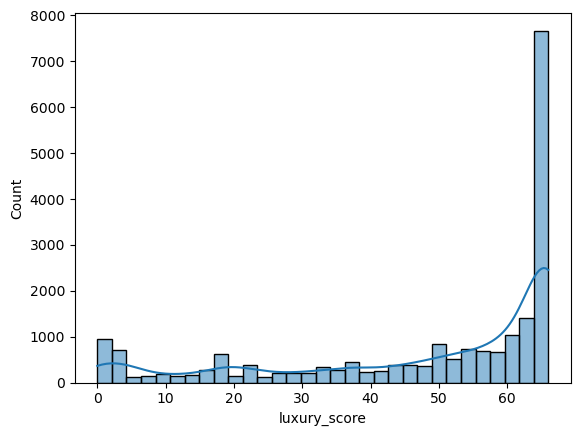

In [407]:
sns.histplot(df["luxury_score"], kde=True)

<Axes: xlabel='luxury_score'>

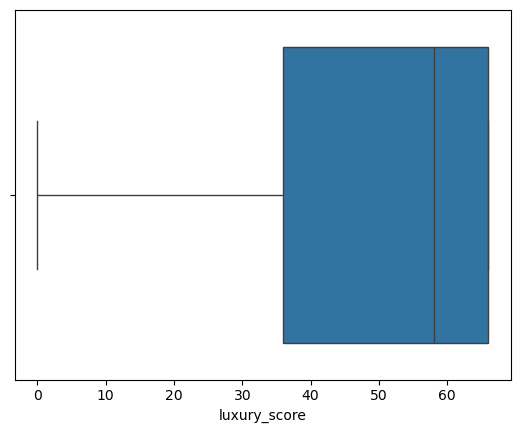

In [408]:
sns.boxplot(x=df["luxury_score"])

In [409]:
x = df[df["price_per_sqft"] <= 20000]
(x["area_sqft"] / x["bedrooms"]).quantile(0.05)

np.float64(272.251)

In [410]:
x = df[df["price_per_sqft"] <= 20000]
(x["area_sqft"] / x["bedrooms"]).quantile(0.05)

np.float64(272.251)

In [411]:
df[(df["area_sqft"] / df["bedrooms"]) < 272.251]

,society,bedrooms,baths,nearby_locations_and_other_facilities,rooms,link,floors,furnished,other_business_and_communication_facilities,other_community_facilities,lawn_or_garden,other_healthcare_and_recreation_facilities,price,area,area_sqft,servant_quarters,kitchens,store_rooms,total_rooms,price_per_sqft,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,servant_quarters_flag,store_rooms_flag,kitchens_flag,other_rooms,luxury_score,furnishing_score,agePossession
5481,DHA Defence,3.0,4.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '3', 'Bathrooms': '4', 'Kitchens'...",https://www.zameen.com/Property/dha_defence_ma...,3.0,True,True,True,True,True,1.50,2.5,680.6275,NaN,2.0,NaN,NaN,22058.823529,1,1,1,1,1,1,1,1,1,1,1,0,1,66,25,New Property
5796,DHA Defence,3.0,4.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '3', 'Bathrooms': '4', 'Servant Q...",https://www.zameen.com/Property/dha_defence_ma...,2.0,True,True,True,True,True,1.50,2.5,680.6275,1.0,2.0,NaN,NaN,22058.823529,1,1,1,1,1,1,1,1,1,0,1,0,1,66,25,New Property
6099,DHA Defence,6.0,5.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '3', 'Bathrooms': '3', 'Servant Q...",https://www.zameen.com/Property/dha_phase_6_dh...,2.0,True,True,True,True,True,3.90,5.0,1361.2550,1.0,1.0,1.0,2.0,28676.470588,1,1,1,1,1,1,1,1,1,0,0,0,0,66,25,New Property
6345,DHA Defence,3.0,3.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...",{},https://www.zameen.com/Property/dha_defence_de...,NaN,NaN,NaN,NaN,NaN,NaN,1.25,2.5,680.6275,NaN,NaN,NaN,NaN,18382.352941,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,Undefined
6520,DHA Defence,6.0,7.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '6', 'Bathrooms': '7', 'Servant Q...",https://www.zameen.com/Property/dha_9_town_dha...,NaN,True,True,True,NaN,NaN,2.45,5.0,1361.2550,2.0,2.0,2.0,4.0,18014.705882,1,1,1,1,1,1,1,1,1,0,0,0,1,57,25,New Property
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21176,Lahore Medical Housing Society,8.0,6.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '4', 'Bathrooms': '5', 'Servant Q...",https://www.zameen.com/Property/lahore_lahore_...,3.0,True,True,True,True,True,1.55,5.0,1361.2550,NaN,NaN,NaN,NaN,11397.058824,1,1,1,1,1,1,1,1,1,0,0,0,1,66,25,New Property
21177,Lahore Medical Housing Society,3.0,3.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...",{},https://www.zameen.com/Property/lahore_lahore_...,NaN,NaN,NaN,NaN,NaN,NaN,1.05,2.2,598.9522,NaN,NaN,NaN,NaN,17546.791444,0,0,0,0,0,0,0,0,0,0,0,0,0,4,0,Undefined
21181,Lahore Medical Housing Society,3.0,3.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '3', 'Bathrooms': '3'}",https://www.zameen.com/Property/lahore_lahore_...,NaN,NaN,NaN,NaN,NaN,NaN,0.85,2.5,680.6275,NaN,2.0,NaN,NaN,12500.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,10,5,New Property
21182,Lahore Medical Housing Society,4.0,4.0,"Nearby Schools, Nearby Hospitals, Nearby Shopp...","{'Bedrooms': '4', 'Bathrooms': '4', 'Kitchens'...",https://www.zameen.com/Property/lahore_lahore_...,2.0,True,NaN,NaN,NaN,NaN,1.55,3.4,925.6534,1.0,NaN,NaN,NaN,16760.380623,1,1,0,0,1,0,0,0,0,0,0,0,0,17,16,New Property


In [412]:
df = df[(df["area_sqft"] / df["bedrooms"]) >= 272.251]

In [413]:
df.shape

(20047, 36)

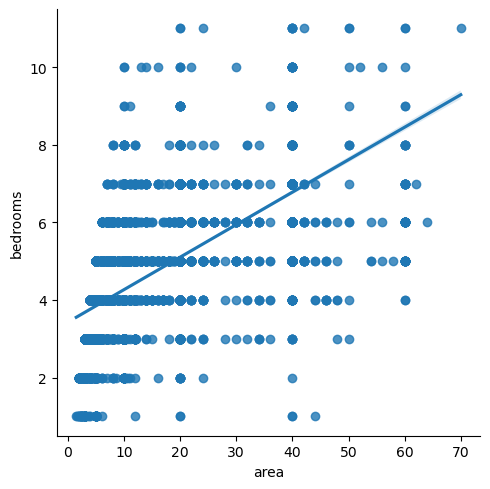

In [414]:
import seaborn as sns

sns.lmplot(data=df, x="area", y="bedrooms")


In [415]:
df.to_csv("house_outlier_treatment.csv")